In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [14]:
df=pd.read_csv("Ice_cream selling data.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


<Axes: xlabel='Temperature (°C)', ylabel='Count'>

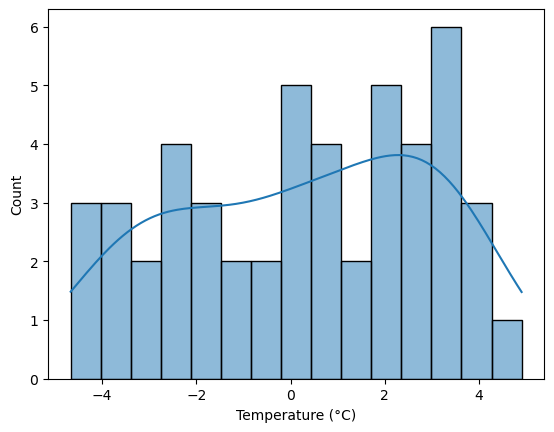

In [15]:
sns.histplot(data=df, x="Temperature (°C)", kde=True, bins=15)

<Axes: xlabel='Ice Cream Sales (units)', ylabel='Count'>

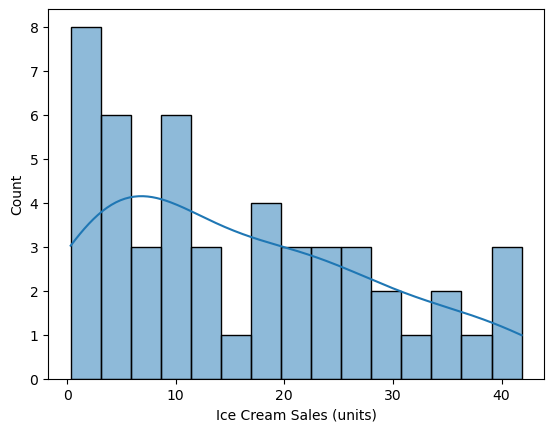

In [16]:
sns.histplot(data=df, x="Ice Cream Sales (units)", kde=True, bins=15)

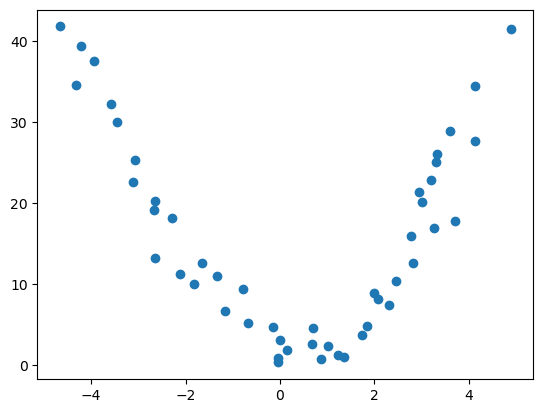

In [17]:
plt.scatter(df["Temperature (°C)"],df["Ice Cream Sales (units)"])

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

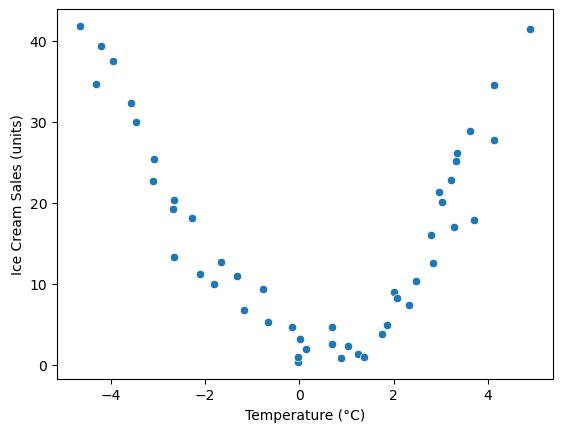

In [18]:
sns.scatterplot(data=df,x="Temperature (°C)", y="Ice Cream Sales (units)")

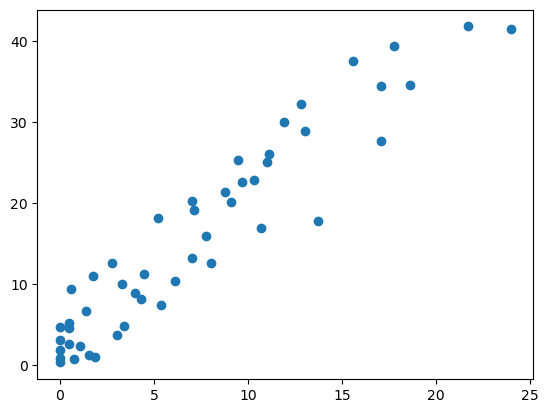

In [19]:
plt.scatter(x=df["Temperature (°C)"]*df["Temperature (°C)"],y=df["Ice Cream Sales (units)"])

In [20]:
x=df.drop("Ice Cream Sales (units)",axis=1)
y=df["Ice Cream Sales (units)"]

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
print(x_train_poly)
x_test_poly=poly.transform(x_test)
print(x_test_poly)

[[ 1.00000000e+00 -2.11186969e+00  4.45999359e+00]
 [ 1.00000000e+00 -3.57855372e+00  1.28060467e+01]
 [ 1.00000000e+00  2.31859124e+00  5.37586534e+00]
 [ 1.00000000e+00 -2.67246083e+00  7.14204687e+00]
 [ 1.00000000e+00 -3.94966109e+00  1.55998227e+01]
 [ 1.00000000e+00 -3.10844012e+00  9.66239999e+00]
 [ 1.00000000e+00  3.21136614e+00  1.03128725e+01]
 [ 1.00000000e+00  3.27004407e+00  1.06931882e+01]
 [ 1.00000000e+00  4.13086796e+00  1.70640701e+01]
 [ 1.00000000e+00 -1.32637898e+00  1.75928121e+00]
 [ 1.00000000e+00 -2.65228679e+00  7.03462523e+00]
 [ 1.00000000e+00 -1.17312327e+00  1.37621820e+00]
 [ 1.00000000e+00  6.88780908e-01  4.74419139e-01]
 [ 1.00000000e+00  2.07510060e+00  4.30604249e+00]
 [ 1.00000000e+00  1.74000001e+00  3.02760004e+00]
 [ 1.00000000e+00 -4.66226268e+00  2.17366933e+01]
 [ 1.00000000e+00  3.33593241e+00  1.11284451e+01]
 [ 1.00000000e+00  1.99931037e+00  3.99724195e+00]
 [ 1.00000000e+00 -3.45571170e+00  1.19419433e+01]
 [ 1.00000000e+00  1.35981267e+

In [24]:
model=LinearRegression()
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

3.2299819836597266
14.878796440981466
0.8430551371938843
[ 0.         -0.70641926  1.87145125]
2.7683058295738636


In [25]:
df=pd.read_csv("Fish.csv")

In [26]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [34]:
x=df.drop(["Species","Weight"],axis=1)
y=df["Weight"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

0.9672675055786748
0.9609431981523922
-422.82939763586364
-428.9175487768359
-1306.7895109267881
-3862.1572730379844
-7218.970277291126


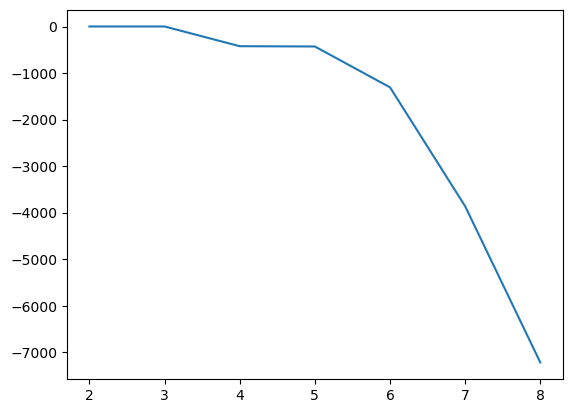

In [36]:
from sklearn.preprocessing import PolynomialFeatures
r2=[]
for i in range(2,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    # print(x_train_poly)
    x_test_poly=poly.transform(x_test)
    # print(x_test_poly)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    # print(mean_absolute_error(y_test,y_pred))
    # print(mean_squared_error(y_test,y_pred))
    # print(r2_score(y_test,y_pred))
    # print(model.coef_)
    # print(model.intercept_)
    r2.append(r2_score(y_test,y_pred))
    print(r2_score(y_test,y_pred))
plt.plot(range(2,9),r2)